# PINN pro 1D lineární elastostatiku

Cílem je pomocí **Physics-Informed Neural Network (PINN)** aproximovat posunutí jednodimenzionální elastické tyče.

## Formulace úlohy

Uvažujeme tyč na intervalu

$$
\Omega=(0,1)
$$

s konstantním Youngovým modulem $E>0$. Předepsané přesné řešení je

$$
u(x)=a\sin(2\pi x), \qquad a>0.
$$

Deformace a napětí jsou

$$
\varepsilon(x)=u'(x), \qquad \sigma(x)=E\,u'(x).
$$

Rovnice rovnováhy má tvar

$$
\sigma'(x)+b(x)=0,
$$

tedy

$$
\frac{\mathrm d}{\mathrm dx}\left(Eu'(x)\right)+b(x)=0.
$$

Pro zvolené přesné řešení vychází objemová síla

$$
b(x)=4\pi^2Ea\sin(2\pi x).
$$

Okrajové podmínky jsou

$$
u(0)=0, \qquad u(1)=0.
$$

Aby se tyř lokálně nepřeklopila nebo nestlačila do jednoho bodu, požadujeme $1+u'(x)>0$, a proto volíme

$$
0<a<\frac{1}{2\pi}.
$$


## 1. Import knihoven

In [1]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import torch
import torch.nn as nn


/home/eliska/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2. Nastavení parametrů

Zde se nastavuje materiál, amplituda, počty bodů a délka trénování.

- `USE_DATA=True`: hybridní PINN s několika známými hodnotami řešení.
- `USE_DATA=False`: čistá PINN založená pouze na PDE a okrajových podmínkách.
- `N_PDE_TRAIN`: kolokační body použité ve fyzikální loss.
- `N_PDE_TEST`: nezávislé body pro závěrečnou kontrolu PDE.
- `N_DATA_TRAIN`: známé hodnoty použité při trénování.
- `N_DATA_TEST`: známé hodnoty použité pouze při testování.

Celkem proběhne 2000 epoch. Prvních 2000 používá Adam a posledních 100 L-BFGS.

In [2]:
USE_DATA = True  # False -> cista PINN bez dat

L = 1.0
E_CONST = 1.0
AMPLITUDE = 0.01  # 0 < a < 1/(2*pi)


N_PDE_TRAIN = 200
N_PDE_TEST = 100

# Supervizovana data se vytvori jen pri USE_DATA=True.
N_DATA_TRAIN = 80
N_DATA_TEST = 20

EPOCHS = 2000
LBFGS_EPOCHS = 100  
LR = 1e-3

torch.manual_seed(42)


## 3. Přesné řešení a fyzikální veličiny


In [3]:
def exact_solution(x):
    """Analyticke reseni u(x) = a*sin(2*pi*x)."""
    return AMPLITUDE * torch.sin(2.0 * torch.pi * x)


def young_modulus(x):
    """Konstantni Younguv modul E."""
    return E_CONST * torch.ones_like(x)


def body_force(x):
    """b(x) odvozena z rovnovahy (E*u')' + b = 0."""
    return (
        4.0
        * torch.pi**2
        * E_CONST
        * AMPLITUDE
        * torch.sin(2.0 * torch.pi * x)
    )


## 4. Neuronová síť

In [ ]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


model = PINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)


## 5. Fyzikální trénovací a testovací body

V bodech `x_pde_train` se během trénování kontroluje reziduum rovnice

$$
r_\theta(x)=\frac{\mathrm d}{\mathrm dx}\left(Eu_\theta'(x)\right)+b(x).
$$

In [5]:
x_pde_train = torch.linspace(0.0, L, N_PDE_TRAIN).view(-1, 1)
x_pde_train.requires_grad_(True)


test_generator = torch.Generator().manual_seed(123)
x_pde_test = L * torch.rand(N_PDE_TEST, 1, generator=test_generator)
x_pde_test, _ = torch.sort(x_pde_test, dim=0)
x_pde_test.requires_grad_(True)


tensor([[0.0114],
        [0.0126],
        [0.0275],
        [0.0353],
        [0.0390],
        [0.0740],
        [0.0756],
        [0.0772],
        [0.0950],
        [0.0969],
        [0.1025],
        [0.1166],
        [0.1186],
        [0.1366],
        [0.1459],
        [0.1479],
        [0.1634],
        [0.1841],
        [0.1908],
        [0.1955],
        [0.1966],
        [0.2251],
        [0.2318],
        [0.2517],
        [0.2745],
        [0.2775],
        [0.2961],
        [0.3009],
        [0.3033],
        [0.3111],
        [0.3153],
        [0.3164],
        [0.3565],
        [0.3821],
        [0.3834],
        [0.3950],
        [0.4017],
        [0.4066],
        [0.4220],
        [0.4340],
        [0.4354],
        [0.4451],
        [0.4527],
        [0.4545],
        [0.4606],
        [0.4702],
        [0.5112],
        [0.5159],
        [0.5166],
        [0.5183],
        [0.5201],
        [0.5299],
        [0.5331],
        [0.5786],
        [0.5789],
        [0

## 6. Volitelná supervizovaná data

Při `USE_DATA=True` zná síť několik přesných hodnot $u(x_i)$. Datová loss je

$$
L_{\mathrm{data}}
=
\frac{1}{N_d}\sum_{i=1}^{N_d}
\left(u_\theta(x_i)-u(x_i)\right)^2.
$$

In [6]:


if USE_DATA:
    # Vnitrni body, aby data zbytecne neduplikovala okrajove podminky.
    x_data_train = torch.linspace(
        0.0,
        L,
        N_DATA_TRAIN + 2,
    )[1:-1].view(-1, 1)
    u_data_train = exact_solution(x_data_train)

    data_test_generator = torch.Generator().manual_seed(456)
    x_data_test = L * torch.rand(
        N_DATA_TEST,
        1,
        generator=data_test_generator,
    )
    x_data_test, _ = torch.sort(x_data_test, dim=0)
    u_data_test = exact_solution(x_data_test)

    print(
        f"Supervizovana data: {len(x_data_train)} trenovacich, "
        f"{len(x_data_test)} testovacich bodu."
    )


Supervizovana data: 80 trenovacich, 20 testovacich bodu.


## 7. Ztrátová funkce a trénování

Celková ztrátová funkce je

$$
L=L_{\mathrm{PDE}}+L_{\mathrm{BC}}+L_{\mathrm{data}},
$$

kde

$$
L_{\mathrm{PDE}}
=
\frac{1}{N_c}\sum_i r_\theta(x_i)^2
$$

a

$$
L_{\mathrm{BC}}
=
u_\theta(0)^2+u_\theta(1)^2.
$$

Pokud je `USE_DATA=False`, položí se $L_{\mathrm{data}}=0$.

Trénování je full-batch: v každé epoše se použijí všechny trénovací body.

In [7]:
loss_history = []
pde_loss_history = []
bc_loss_history = []
data_loss_history = []
snimky = {}
x_plot = torch.linspace(0.0, L, 200).view(-1, 1)

ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS


def compute_losses():
    """Spocita vsechny slozky trenovaci loss."""
    u = model(x_pde_train)

    du = torch.autograd.grad(
        outputs=u,
        inputs=x_pde_train,
        grad_outputs=torch.ones_like(u),
        create_graph=True,
    )[0]

    sigma = young_modulus(x_pde_train) * du

    dsigma = torch.autograd.grad(
        outputs=sigma,
        inputs=x_pde_train,
        grad_outputs=torch.ones_like(sigma),
        create_graph=True,
    )[0]

    residual = dsigma + body_force(x_pde_train)
    loss_pde = torch.mean(residual**2)

    loss_bc_left = torch.mean(model(torch.tensor([[0.0]])) ** 2)
    loss_bc_right = torch.mean(model(torch.tensor([[L]])) ** 2)
    loss_bc = loss_bc_left + loss_bc_right

    if USE_DATA:
        prediction = model(x_data_train)
        loss_data = torch.mean((prediction - u_data_train) ** 2)
    else:
        loss_data = torch.tensor(0.0)

    loss = loss_pde + loss_bc + loss_data
    return loss, loss_pde, loss_bc, loss_data


def save_progress(epoch, loss, loss_pde, loss_bc, loss_data):
    """Ulozi loss a aktualni predikci."""
    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    bc_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())

    with torch.no_grad():
        snimky[epoch] = model(x_plot).detach().numpy().copy()




for epoch in range(ADAM_EPOCHS):
    optimizer_adam.zero_grad()
    x_pde_train.grad = None

    loss, loss_pde, loss_bc, loss_data = compute_losses()
    loss.backward()
    optimizer_adam.step()

    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    bc_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())

    if epoch % 100 == 0:
        print(
            f"Adam  | epocha {epoch:5d} | loss = {loss.item():.6e} | "
            f"PDE = {loss_pde.item():.6e} | BC = {loss_bc.item():.6e}"
        )
        with torch.no_grad():
            snimky[epoch] = model(x_plot).detach().numpy().copy()





optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=20,
    history_size=50,
    line_search_fn="strong_wolfe",
)

for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch

    def closure():
        optimizer_lbfgs.zero_grad()
        x_pde_train.grad = None

        loss, _, _, _ = compute_losses()
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)

    # Loss po provedeni aktualizace parametru.
    loss, loss_pde, loss_bc, loss_data = compute_losses()

    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    bc_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())

    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(
            f"L-BFGS | epocha {epoch:5d} | loss = {loss.item():.6e} | "
            f"PDE = {loss_pde.item():.6e} | BC = {loss_bc.item():.6e}"
        )
        with torch.no_grad():
            snimky[epoch] = model(x_plot).detach().numpy().copy()


Adam  | epocha     0 | loss = 3.209492e-01 | PDE = 2.017743e-01 | BC = 7.694734e-02
Adam  | epocha   100 | loss = 3.588562e-02 | PDE = 3.488448e-02 | BC = 9.103143e-04
Adam  | epocha   200 | loss = 2.359232e-02 | PDE = 2.356973e-02 | BC = 1.614784e-05
Adam  | epocha   300 | loss = 9.065880e-03 | PDE = 8.942506e-03 | BC = 1.025616e-04
Adam  | epocha   400 | loss = 4.423158e-03 | PDE = 4.406417e-03 | BC = 1.302261e-05
Adam  | epocha   500 | loss = 3.236284e-03 | PDE = 3.220981e-03 | BC = 1.219182e-05
Adam  | epocha   600 | loss = 2.059978e-03 | PDE = 2.048300e-03 | BC = 9.534858e-06
Adam  | epocha   700 | loss = 1.340261e-03 | PDE = 1.333727e-03 | BC = 5.383721e-06
Adam  | epocha   800 | loss = 9.460625e-04 | PDE = 9.425408e-04 | BC = 2.896943e-06
Adam  | epocha   900 | loss = 6.583430e-04 | PDE = 6.563131e-04 | BC = 1.665104e-06
Adam  | epocha  1000 | loss = 4.337528e-04 | PDE = 4.325174e-04 | BC = 1.012884e-06
Adam  | epocha  1100 | loss = 2.509860e-04 | PDE = 2.502510e-04 | BC = 6.040

## 8. Vyhodnocení na kolokačních testovacích bodech

Závěrečné vyhodnocení obsahuje pouze metriky vypočtené na nezávislých bodech `x_pde_test`, které nebyly použity při trénování:

- **$R^2$ skóre** predikovaného posunutí,
- **relativní $L^2$ chyba** posunutí,
- **MSE PDE rezidua**.

Koeficient determinace je

$$
R^2
=
1-
\frac{\sum_i\left(u_\theta(x_i)-u(x_i)\right)^2}
{\sum_i\left(u(x_i)-\bar{u}\right)^2}.
$$

Relativní chyba je

$$
\frac{\lVert u_\theta-u\rVert_2}{\lVert u\rVert_2}.
$$

In [8]:
model.eval()

u_pde_test_prediction = model(x_pde_test)

du_pde_test = torch.autograd.grad(
    outputs=u_pde_test_prediction,
    inputs=x_pde_test,
    grad_outputs=torch.ones_like(u_pde_test_prediction),
    create_graph=True,
)[0]

sigma_pde_test = young_modulus(x_pde_test) * du_pde_test

dsigma_pde_test = torch.autograd.grad(
    outputs=sigma_pde_test,
    inputs=x_pde_test,
    grad_outputs=torch.ones_like(sigma_pde_test),
    create_graph=True,
)[0]

residual_pde_test = dsigma_pde_test + body_force(x_pde_test)
pde_test_mse = torch.mean(residual_pde_test**2).detach().item()


# R2 a relativni L2 chyba na stejnych kolokacnich testovacich bodech.
with torch.no_grad():
    u_test_prediction = model(x_pde_test)
    u_test_exact = exact_solution(x_pde_test)

    ss_res = torch.sum((u_test_prediction - u_test_exact) ** 2)
    ss_tot = torch.sum((u_test_exact - torch.mean(u_test_exact)) ** 2)
    r2_test = (1.0 - ss_res / ss_tot).item()

    relative_l2_test = (
        torch.linalg.vector_norm(u_test_prediction - u_test_exact)
        / torch.linalg.vector_norm(u_test_exact)
    ).item()


metrics = {
    "R2_collocation_test": r2_test,
    "relative_L2_collocation_test": relative_l2_test,
    "PDE_test_MSE": pde_test_mse,
}


print("=" * 60)
print("TESTOVACI VYSLEDKY PINN")
print("=" * 60)
print(f"R2 na kolokacnich testovacich bodech: {r2_test:.8f}")
print(f"Relativni L2 chyba na techto bodech:   {relative_l2_test:.6e}")
print(f"MSE PDE rezidua na techto bodech:      {pde_test_mse:.6e}")
print("=" * 60)

metrics


TESTOVACI VYSLEDKY PINN
R2 na kolokacnich testovacich bodech: 0.99999994
Relativni L2 chyba na techto bodech:   2.084693e-04
MSE PDE rezidua na techto bodech:      1.889614e-07


{'R2_collocation_test': 0.9999999403953552,
 'relative_L2_collocation_test': 0.00020846926781814545,
 'PDE_test_MSE': 1.889614225092373e-07}

In [ ]:
def plot_data_split():
    """Zobrazi fyzikalni a pripadne supervizovane train/test body."""
    ncols = 2 if USE_DATA else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 4.5))
    if ncols == 1:
        axes = [axes]

    ax_pde = axes[0]
    ax_pde.scatter(
        x_pde_train.detach().numpy(),
        np.ones((len(x_pde_train), 1)),
        color="tab:blue",
        s=25,
        label=f"PDE train ({len(x_pde_train)})",
    )
    ax_pde.scatter(
        x_pde_test.detach().numpy(),
        np.zeros((len(x_pde_test), 1)),
        color="tab:orange",
        marker="x",
        s=25,
        label=f"PDE test ({len(x_pde_test)})",
    )
    ax_pde.set_yticks([0, 1], labels=["test", "train"])
    ax_pde.set_xlabel("x")
    ax_pde.set_title("Fyzikalni kolokacni body")
    ax_pde.set_ylim(-0.5, 1.5)
    ax_pde.legend()
    ax_pde.grid(axis="x")

    if USE_DATA:
        ax_data = axes[1]
        x_dense = torch.linspace(0.0, L, 400).view(-1, 1)
        u_dense = exact_solution(x_dense)
        ax_data.plot(
            x_dense.numpy(),
            u_dense.numpy(),
            "k--",
            linewidth=1.5,
            label="Analyticke reseni",
        )
        ax_data.scatter(
            x_data_train.numpy(),
            u_data_train.numpy(),
            color="tab:blue",
            s=45,
            label=f"Data train ({len(x_data_train)})",
            zorder=3,
        )
        ax_data.scatter(
            x_data_test.numpy(),
            u_data_test.numpy(),
            color="tab:orange",
            marker="x",
            s=45,
            label=f"Data test ({len(x_data_test)})",
            zorder=3,
        )
        ax_data.set_xlabel("x")
        ax_data.set_ylabel("u(x)")
        ax_data.set_title("Supervizovana data")
        ax_data.legend()
        ax_data.grid()

    fig.tight_layout()

    plt.show()
    return fig, axes


def plot_solution(show_snapshots=True):
    """Zobrazi analyticke reseni a vyvoj, pripadne jen finalni PINN."""
    fig, ax = plt.subplots(figsize=(8, 5))

    if show_snapshots:
        barvy = cm.viridis(np.linspace(0.0, 0.9, len(snimky)))
        for (epoch, u_snap), barva in zip(snimky.items(), barvy):
            ax.plot(
                x_plot.numpy(),
                u_snap,
                color=barva,
                alpha=0.65,
                label=f"epocha {epoch}",
            )
    else:
        with torch.no_grad():
            u_prediction = model(x_plot).detach().numpy()
        ax.plot(
            x_plot.numpy(),
            u_prediction,
            color="tab:blue",
            linewidth=2,
            label="PINN",
        )

    u_analytical = exact_solution(x_plot)
    ax.plot(
        x_plot.numpy(),
        u_analytical.numpy(),
        "r--",
        linewidth=2,
        label=r"Analyticke $u(x)=a\sin(2\pi x)$",
    )
    ax.set_xlabel("x")
    ax.set_ylabel("u(x)")
    ax.legend()
    ax.grid()
    fig.tight_layout()
    #plt.savefig("pinn_reseni.pdf", bbox_inches="tight")
    plt.show()
    return fig, ax


def plot_loss():
    """Zobrazi celkovou i jednotlive slozky ztratove funkce."""
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(loss_history, label="celkova")
    ax.plot(pde_loss_history, label="PDE")
    ax.plot(bc_loss_history, label="okrajove podminky")
    if USE_DATA:
        ax.plot(data_loss_history, label="supervizovana data")
    ax.axvline(
        ADAM_EPOCHS,
        color="black",
        linestyle=":",
        label="prechod na L-BFGS",
    )
    ax.set_yscale("log")
    ax.set_xlabel("Epocha")
    ax.set_ylabel("Ztrata")
    ax.legend()
    ax.grid()
    fig.tight_layout()
    #plt.savefig("pinn_loss.pdf", bbox_inches="tight")
    plt.show()
    return fig, ax


## 9. Vizualizační funkce


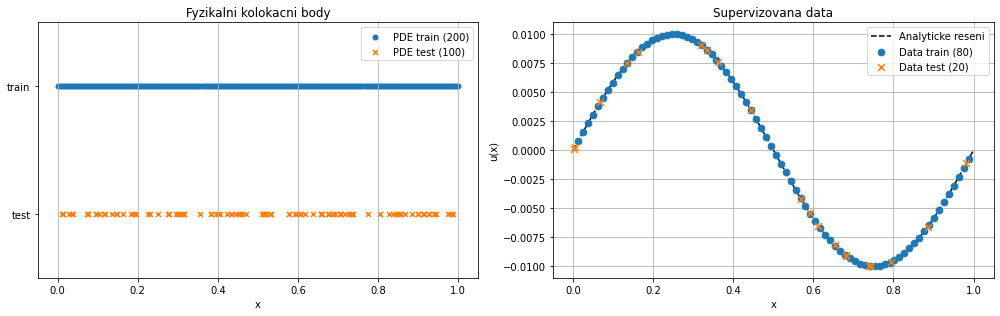

(<Figure size 1008x324 with 2 Axes>,
 array([<Axes: title={'center': 'Fyzikalni kolokacni body'}, xlabel='x'>,
        <Axes: title={'center': 'Supervizovana data'}, xlabel='x', ylabel='u(x)'>],
       dtype=object))

In [10]:
plot_data_split()


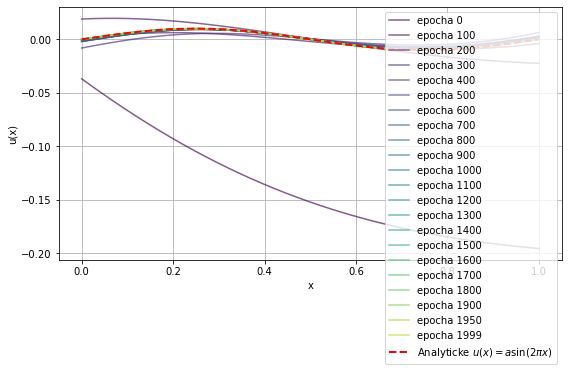

(<Figure size 576x360 with 1 Axes>, <Axes: xlabel='x', ylabel='u(x)'>)

In [11]:
plot_solution()


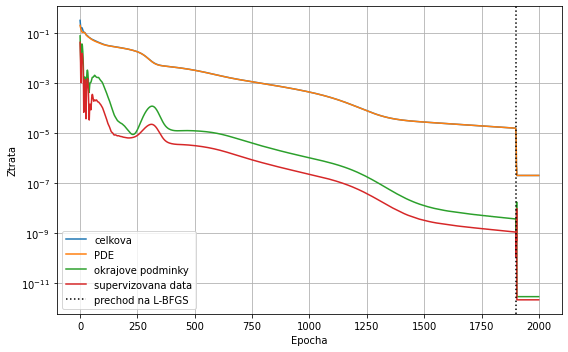

(<Figure size 576x360 with 1 Axes>, <Axes: xlabel='Epocha', ylabel='Ztrata'>)

In [12]:
plot_loss()


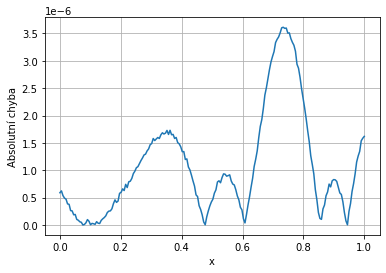

In [ ]:
u_pred = model(x_plot).detach()
u_exact = exact_solution(x_plot)
absolute_error = torch.abs(u_pred - u_exact)

plt.plot(x_plot.numpy(), absolute_error.numpy())
plt.xlabel("x")
plt.ylabel("Absolutní chyba")
plt.grid()
#plt.savefig("pinn_absErr.pdf", bbox_inches="tight")
plt.show()